In [59]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import random
import numpy as np
import torch
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from syd import make_viewer, Viewer
from tqdm import tqdm

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import format_spines, beeswarm, errorPlot, save_figure
from vrAnalysis.processors.placefields import get_placefield
from vrAnalysis.metrics import FractionActive
from dimensionality_manuscript.registry import PopulationRegistry, get_activity_parameters, TimeSplit
from dimensionality_manuscript.regression_models.hyperparameters import PlaceFieldHyperparameters

plt.rcParams["font.size"] = 14

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
registry = PopulationRegistry()

In [75]:
from vrAnalysis.processors import SpkmapProcessor


idx_session = 27
spks_type = "oasis"
ap_name = "preserved" # default / raw / preserved
split = "full"

session = sessiondb.iter_sessions(imaging=True)[idx_session]
activity_parameters = get_activity_parameters(ap_name)
population, frame_behavior = registry.get_population(session, spks_type)
source_data, target_data = population.get_split_data(
    registry.time_split[split],
    scale=activity_parameters.scale, 
    scale_type=activity_parameters.scale_type,
    pre_split=activity_parameters.presplit,
)
idx = np.array(population.get_split_times(registry.time_split[split], within_idx_samples=False))
frame_behavior = frame_behavior.filter(idx)

data = torch.cat([source_data, target_data], dim=0)

spkmap = SpkmapProcessor(session)
reliability = spkmap.get_reliability(use_session_filters=False).filter_rois(population.idx_neurons).values

fraction_active = FractionActive().participation_ratio(data.numpy(), axis=1)

print(session)
print(data.shape, frame_behavior.shape, reliability.shape, fraction_active.shape)

B2Session(mouse_name='ATL020', date='2023-04-05', session_id='701', spks_type='oasis')
torch.Size([5775, 7577]) 7577 (1, 5775) (5775,)


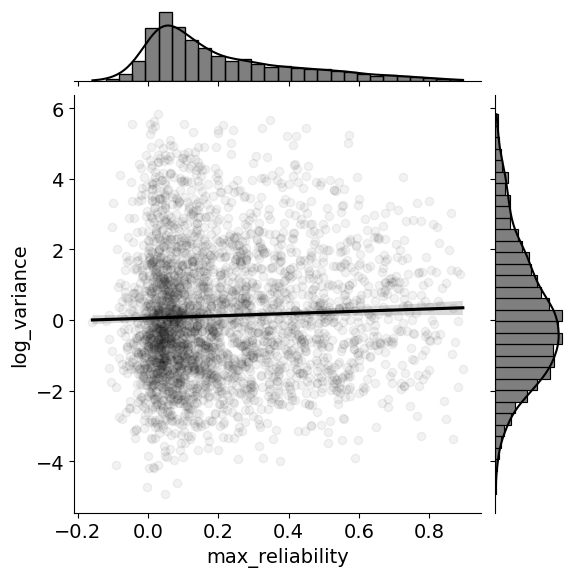

In [77]:
min = torch.min(data, dim=1).values
max = torch.max(data, dim=1).values
skew = torch.mean(torch.pow(data - torch.mean(data, dim=1, keepdims=True), 3), dim=1)
variance = torch.var(data, dim=1)
log_variance = torch.log(variance + 1e-3)
max_reliability = reliability.max(axis=0)

idx_active = fraction_active > 0.02

df = pd.DataFrame({"max_reliability": max_reliability, "max": max, "skew": skew, "variance": variance, "log_variance": log_variance, "fraction_active": fraction_active})
sns.jointplot(data=df[idx_active], x="max_reliability", y="log_variance", kind="reg", color="black", joint_kws={'scatter_kws': {'alpha': 0.05}})